In [1]:
import numpy as np

from easydynamics.sample_model import Gaussian
from easydynamics.sample_model import Lorentzian
from easydynamics.sample_model import DampedHarmonicOscillator
from easydynamics.sample_model import Polynomial
from easydynamics.sample_model import DeltaFunction
from easydynamics.sample_model import SampleModel


import matplotlib.pyplot as plt


%matplotlib widget

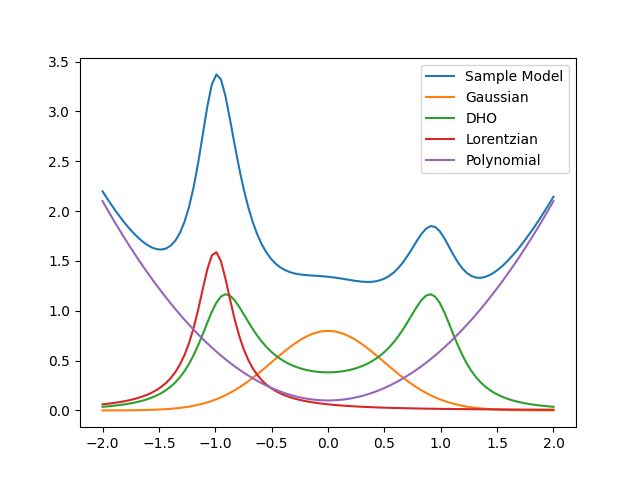

In [2]:
sample_model=SampleModel(name='sample_model')

# Creating components
gaussian=Gaussian(name='Gaussian',width=0.5,area=1)
dho = DampedHarmonicOscillator(name='DHO',center=1.0,width=0.3,area=2.0)
lorentzian = Lorentzian(name='Lorentzian',center=-1.0,width=0.2,area=1.0)
polynomial = Polynomial(name='Polynomial',coefficients=[0.1, 0, 0.5])  # y=0.1+0.5*x^2

sample_model.add_component(gaussian)
sample_model.add_component(dho)
sample_model.add_component(lorentzian)
sample_model.add_component(polynomial)


x=np.linspace(-2, 2, 100)

plt.figure()
y=sample_model.evaluate(x)
plt.plot(x, y, label='Sample Model')

for component in sample_model.components.values():
    y = component.evaluate(x)
    plt.plot(x, y, label=component.name)

plt.legend()
plt.show()

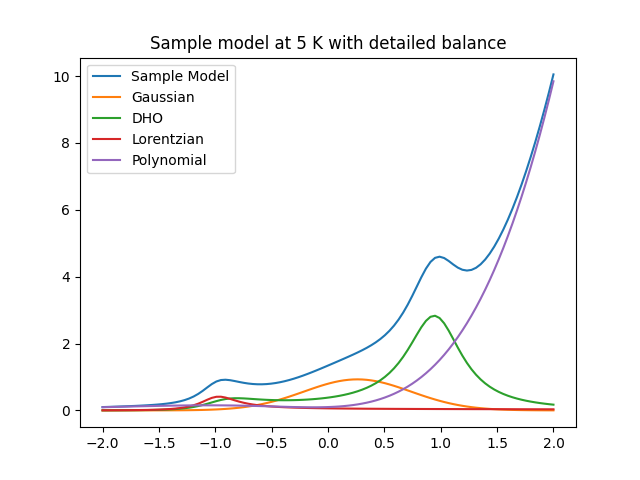

In [3]:
sample_model=SampleModel(name='sample_model')
sample_model.temperature=5
sample_model.use_detailed_balance=True
sample_model.normalise_detailed_balance=True

# Creating components
gaussian=Gaussian(name='Gaussian',width=0.5,area=1)
dho = DampedHarmonicOscillator(name='DHO',center=1.0,width=0.3,area=2.0)
lorentzian = Lorentzian(name='Lorentzian',center=-1.0,width=0.2,area=1.0)
polynomial = Polynomial(name='Polynomial',coefficients=[0.1, 0, 0.5])  # y=0.1+0.5*x^2

sample_model.add_component(gaussian)
sample_model.add_component(dho)
sample_model.add_component(lorentzian)
sample_model.add_component(polynomial)


x=np.linspace(-2, 2, 100)

plt.figure()
y=sample_model.evaluate(x)
plt.plot(x, y, label='Sample Model')

for component in sample_model.values():
    y=sample_model.evaluate_component(x,component.name)
    plt.plot(x, y, label=component.name)

plt.legend()
plt.title('Sample model at 5 K with detailed balance')
plt.show()

In [4]:
sample_model['Gaussian'].fix_all_parameters()

In [5]:
sample_mode=SampleModel(name="TestSampleModel")
component1 = Gaussian(
    name="TestGaussian", area=1.0, center=0.0, width=1.0, unit="meV"
)
component2 = Lorentzian(
    name="TestLorentzian", area=2.0, center=1.0, width=0.5, unit="meV"
)
sample_model.add_component(component1)
sample_model.add_component(component2)

In [6]:
sample_mode=SampleModel(name="TestSampleModel")
not sample_mode.components

True

In [7]:
from copy import copy
model = SampleModel(name="TwoComponentModel")
component1 = Gaussian(
    name="TestGaussian1", area=1.0, center=0.0, width=1.0, unit="meV"
)
component2 = Lorentzian(
    name="TestLorentzian1", area=2.0, center=1.0, width=0.5, unit="meV"
)
model.add_component(component1)
model.add_component(component2)

sample_model_with_components=model

model_copy = copy(sample_model_with_components)



assert model_copy is not sample_model_with_components
assert model_copy.name == "copy of " + sample_model_with_components.name
assert len(model_copy.components) == len(
    sample_model_with_components.components
)
for name, comp in sample_model_with_components.components.items():
    copied_comp = model_copy.components[name]
    assert copied_comp is not comp
    assert copied_comp.name == comp.name
    for param_orig, param_copy in zip(
        comp.get_parameters(), copied_comp.get_parameters()
    ):
        assert param_copy is not param_orig
        assert param_copy.name == param_orig.name
        assert param_copy.value == param_orig.value
        assert param_copy.fixed == param_orig.fixed

AssertionError: 

In [9]:
model_copy['TestGaussian1']

Gaussian(name = copy of TestGaussian1, unit = meV,
 area = <Parameter 'TestGaussian1 area': 1.0000 meV, bounds=[0.0:inf]>,
 center = <Parameter 'TestGaussian1 center': 0.0000 meV, bounds=[-inf:inf]>,
 width = <Parameter 'TestGaussian1 width': 1.0000 meV, bounds=[1e-10:inf]>)